
Training Baseline Model...
Training L1 + L2 Regularization Model...
Training L1 + L2 + Dropout Model...

================ MODEL COMPARISON ================

                    Model  Train Accuracy (R² %)  Test Accuracy (R² %)  \
0  Without Regularization                  83.61                  4.92   
1                 L1 + L2                  83.57                  4.90   
2       L1 + L2 + Dropout                  82.03                  5.07   

            MSE       RMSE  
0  9.696970e+11  984731.94  
1  9.699072e+11  984838.69  
2  9.681409e+11  983941.50  


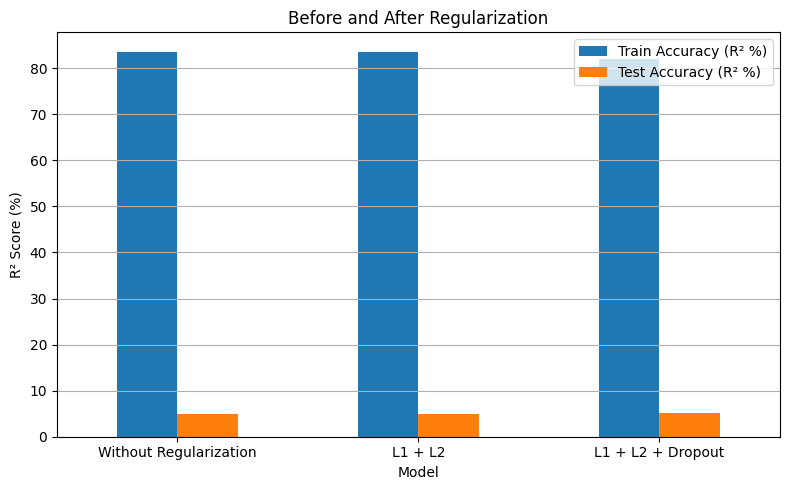

In [ ]:
# riya_varma_23070521118
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

df = pd.read_csv("/content/data.csv")

X = df.drop("price", axis=1)
y = df["price"]

categorical_cols = X.select_dtypes(include="object").columns
numerical_cols = X.select_dtypes(exclude="object").columns

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numerical_cols),
    ("cat", categorical_transformer, categorical_cols)
])

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

def train_model(model_name):

    if model_name == "baseline":
        regularizer = None
        dropout = False

    elif model_name == "l1_l2":
        regularizer = tf.keras.regularizers.l1_l2(
            l1=0.001,
            l2=0.001
        )
        dropout = False

    elif model_name == "dropout":
        regularizer = tf.keras.regularizers.l1_l2(
            l1=0.001,
            l2=0.001
        )
        dropout = True

    model = Sequential()

    model.add(Input(shape=(X_train.shape[1],)))

    model.add(Dense(128,
                    activation="relu",
                    kernel_regularizer=regularizer))
    if dropout:
        model.add(Dropout(0.3))

    model.add(Dense(64,
                    activation="relu",
                    kernel_regularizer=regularizer))
    if dropout:
        model.add(Dropout(0.3))

    model.add(Dense(32,
                    activation="relu",
                    kernel_regularizer=regularizer))
    if dropout:
        model.add(Dropout(0.3))

    model.add(Dense(1))

    model.compile(
        optimizer="adam",
        loss="mse"
    )

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    )

    model.fit(
        X_train,
        y_train,
        validation_split=0.2,
        epochs=200,
        batch_size=32,
        callbacks=[early_stop],
        verbose=0
    )

    # Predictions
    train_pred = model.predict(X_train, verbose=0).ravel()
    test_pred = model.predict(X_test, verbose=0).ravel()

    train_r2 = r2_score(y_train, train_pred)
    test_r2 = r2_score(y_test, test_pred)

    mse = mean_squared_error(y_test, test_pred)
    rmse = np.sqrt(mse)

    return train_r2 * 100, test_r2 * 100, mse, rmse

print("\nTraining Baseline Model...")
baseline = train_model("baseline")

print("Training L1 + L2 Regularization Model...")
l1l2 = train_model("l1_l2")

print("Training L1 + L2 + Dropout Model...")
drop = train_model("dropout")

comparison = pd.DataFrame({

    "Model":[
        "Without Regularization",
        "L1 + L2",
        "L1 + L2 + Dropout"
    ],

    "Train Accuracy (R² %)":[
        baseline[0],
        l1l2[0],
        drop[0]
    ],

    "Test Accuracy (R² %)":[
        baseline[1],
        l1l2[1],
        drop[1]
    ],

    "MSE":[
        baseline[2],
        l1l2[2],
        drop[2]
    ],

    "RMSE":[
        baseline[3],
        l1l2[3],
        drop[3]
    ]

})

print("\n================ MODEL COMPARISON ================\n")
print(comparison.round(2))
comparison.set_index("Model")[[
    "Train Accuracy (R² %)",
    "Test Accuracy (R² %)"
]].plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Before and After Regularization")
plt.ylabel("R² Score (%)")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.tight_layout()
plt.show()